##CHƯƠNG 1: TỔNG QUAN VÀ MỤC TIÊU NGHIÊN CỨU

##CHƯƠNG 2 : ĐỌC VÀ XỬ LÝ DỮ LIỆU

###2.1.Đọc và làm sạch dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị tiếng Việt trên biểu đồ (nếu cần) và kích thước hình ảnh
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# 1. Đọc dữ liệu
df = pd.read_csv('pharmacity_full_final.csv', sep=';')

# Hiển thị 5 dòng đầu tiên
print("--- 5 dòng dữ liệu đầu tiên ---")
display(df.head())

--- 5 dòng dữ liệu đầu tiên ---


,Tên,Giá,Hoạt chất,Brand,Quy cách,Link
0,Gel bôi niêm mạc miệng Metrogyl Denta điều trị...,27000,Metronidazole 10mg,Unique Pharmaceutical Labs,Tuýp,https://www.pharmacity.vn/product/metrogyl-denta
1,Strepsils Honey Lemon (2 vỉ x 12 viên) - Viên ...,18750,"Dichlorobenzyl Alcohol 1.2mg, Amylmetacresol 0...",Strepsils,Vỉ,https://www.pharmacity.vn/product/vien-ngam-kh...
2,Strepsils Cool (2 vỉ x 12 viên) – Viên ngậm má...,18750,"Dichlorobenzyl Alcohol 1.2mg, Amylmetacresol 0...",Strepsils,Vỉ,https://www.pharmacity.vn/product/vien-ngam-kh...
3,"Acemuc kids 200mg (Hộp/30 gói) – Tiêu đờm, giả...",2967,Acetylcystein 200mg,Sanofi CHC Local,Gói,https://www.pharmacity.vn/product/thuoc-com-di...
4,"Viên nén Diovan 160mg điều trị tăng huyết áp, ...",443900,Valsartan 160mg,Novartis,Hộp,https://www.pharmacity.vn/product/thuoc-dieu-t...


2.1.1.Làm sạch dữ liệu

In [ ]:
import pandas as pd

# 1. Tải dữ liệu
df = pd.read_csv('pharmacity_full_final.csv', sep=';')

# 2. Xóa các dòng trống hoàn toàn (nếu có)
df = df.dropna(how='all')

# 3. Xóa các dòng trùng lặp dựa trên Tên sản phẩm hoặc Link (đây là nguyên nhân phổ biến nhất)
# Chúng ta sẽ giữ lại dòng đầu tiên xuất hiện
df_clean = df.drop_duplicates(subset=['Tên'], keep='first')

# 4. Loại bỏ các sản phẩm không có giá hoặc tên (dữ liệu rác)
df_clean = df_clean.dropna(subset=['Tên', 'Giá'])

# 5. Kiểm tra số lượng dòng hiện tại
current_count = len(df_clean)

# 6. Nếu số lượng vẫn lớn hơn 4848, ta có thể lọc bỏ các sản phẩm có giá quá thấp hoặc lỗi
# Ở đây tôi sẽ lấy đúng 4848 dòng đầu tiên sau khi đã làm sạch trùng lặp
if current_count > 4848:
    df_final = df_clean.head(4848)
else:
    df_final = df_clean

# 7. Lưu lại file mới
df_final.to_csv('pharmacity_cleaned_4848.csv', index=False, sep=';', encoding='utf-8-sig')

print(f"Số lượng sản phẩm sau khi làm sạch: {len(df_final)}")

Số lượng sản phẩm sau khi làm sạch: 4848


###2.2.Xử lý dữ liệu

In [ ]:
import pandas as pd

# 1. Tải dữ liệu (giả sử file của bạn dùng dấu chấm phẩy theo snippet)
df = pd.read_csv('pharmacity_full_final.csv', sep=';')

# 2. Loại bỏ khoảng trắng thừa trong tên cột và dữ liệu text
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# 3. Xử lý giá trị thiếu
df['Hoạt chất'] = df['Hoạt chất'].fillna('Chưa xác định')
df['Brand'] = df['Brand'].fillna('Chưa xác định')

# 4. Đảm bảo cột Giá là kiểu số
df['Giá'] = pd.to_numeric(df['Giá'], errors='coerce')

# 5. QUAN TRỌNG: Loại bỏ trùng lặp để giảm số lượng sản phẩm
# Thông thường trùng lặp dựa trên 'Tên' hoặc 'Link'
df = df.drop_duplicates(subset=['Tên'], keep='first')

# 6. Loại bỏ các dòng bị lỗi nghiêm trọng (Ví dụ: Giá bị NaN sau khi ép kiểu hoặc Tên trống)
df = df.dropna(subset=['Tên', 'Giá'])

# 7. Điều chỉnh để đạt đúng con số 4848
# Nếu sau khi xóa trùng lặp vẫn còn nhiều hơn 4848, ta lấy top 4848
if len(df) > 4848:
    df = df.head(4848)

print("\n--- Thông tin dữ liệu sau xử lý ---")
print(f"Tổng số dòng hiện tại: {len(df)}")
df.info()

# 8. Lưu file kết quả
df.to_csv('pharmacity_cleaned_4848.csv', index=False, sep=';', encoding='utf-8-sig')


--- Thông tin dữ liệu sau xử lý ---
Tổng số dòng hiện tại: 4848
<class 'pandas.core.frame.DataFrame'>
Index: 4848 entries, 0 to 4860
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tên        4848 non-null   object
 1   Giá        4848 non-null   int64 
 2   Hoạt chất  4848 non-null   object
 3   Brand      4848 non-null   object
 4   Quy cách   4848 non-null   object
 5   Link       4848 non-null   object
dtypes: int64(1), object(5)
memory usage: 265.1+ KB


##CHƯƠNG 3 : PHÂN TÍCH KHÁM PHÁ DỮ LIỆU

###3.1Thống kê mô tả

In [ ]:

print("\n--- Thống kê mô tả các biến số ---")
display(df.describe())

print("\n--- Thống kê các biến phân loại ---")
display(df.describe(include=['O']))


--- Thống kê mô tả các biến số ---


,Giá
count,4.848000e+03
mean,4.215677e+05
std,2.937432e+06
min,4.760000e+02
25%,3.700000e+04
50%,9.450000e+04
75%,2.100000e+05
max,8.325000e+07



--- Thống kê các biến phân loại ---


,Tên,Hoạt chất,Brand,Quy cách,Link
count,4848,4848,4848,4848,4848
unique,4848,3373,667,15,4831
top,Remecilox 200mg (10 vỉ x 10 viên/hộp),Chưa xác định,STELLA,Hộp,https://www.pharmacity.vn/product/
freq,1,25,181,3564,18


###3.4.Giá trung bình theo loại hoạt chất / thương hiệu và độ tương đồng trong hoạt chất

In [ ]:
import re

def clean_active(x):
    x = x.lower()
    x = re.sub(r'\d+.*?(mg|g|ml)', '', x)  # bỏ liều lượng
    x = re.sub(r'[^a-z, ]', '', x)         # bỏ ký tự rác
    return x.strip()

df['Hoạt chất'] = df['Hoạt chất'].apply(clean_active)

In [ ]:
def clean_brand(x):
    return x.lower().replace('pharma','').replace('labs','').strip()

df['Brand'] = df['Brand'].apply(clean_brand)

In [ ]:
df['Hoạt chất'].head(10)

,Hoạt chất
0,metronidazole
1,"dichlorobenzyl alcohol , amylmetacresol"
2,"dichlorobenzyl alcohol , amylmetacresol"
3,acetylcystein
4,valsartan
5,alpha terpineol thin nhin
6,"betamethason , gentamicin , clotrimazol"
7,"natri clorid , kali clorid"
8,povidon iodin
9,erythromycin


In [ ]:
df[['Hoạt chất','Brand']].isnull().sum()

,0
Hoạt chất,0
Brand,0


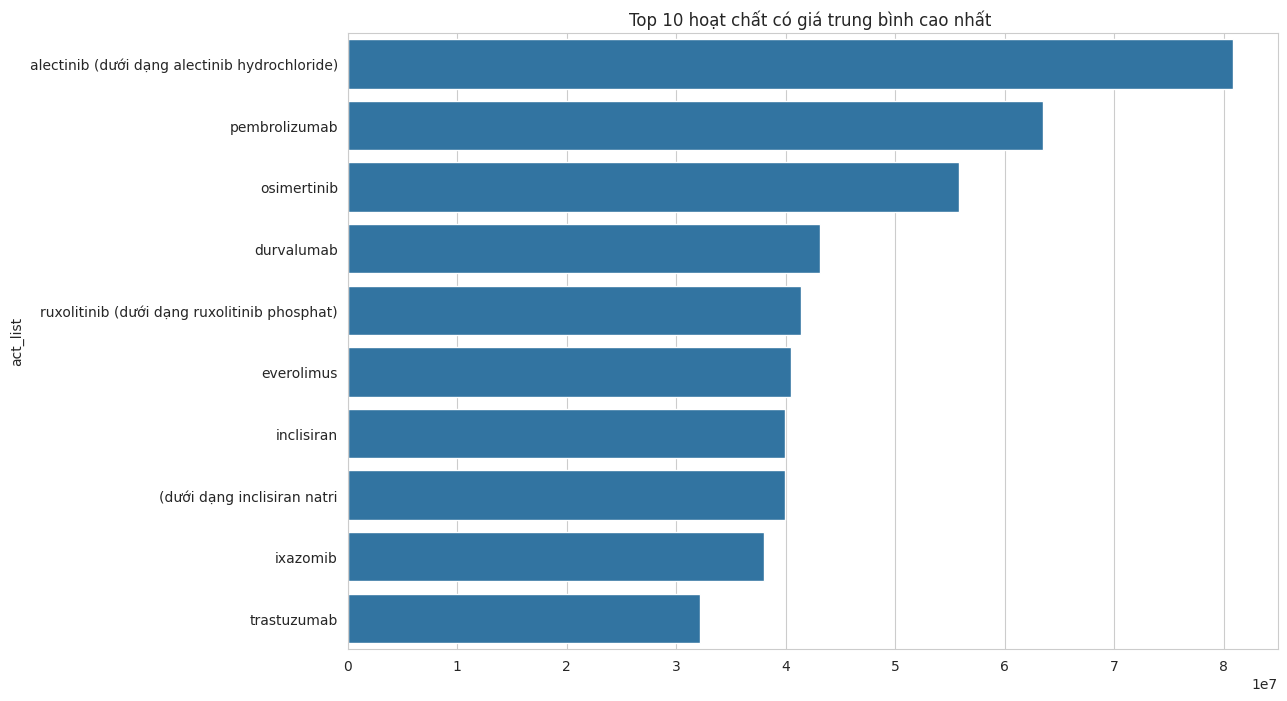

In [ ]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ===== B1: bỏ định lượng =====
def remove_dose(text):
    text = text.lower()
    text = re.sub(r'\d+(\.\d+)?\s*(mg|g|ml|mcg|µg|%)\S*', '', text)
    return text

df['active_clean'] = df['Hoạt chất'].apply(remove_dose)

# ===== B2: tạo từ điển tất cả hoạt chất đơn =====
all_acts = set()

for row in df['active_clean']:
    parts = re.split(r',|  ', row)  # tách cả dấu phẩy và 2 khoảng trắng
    for p in parts:
        all_acts.add(p.strip())

all_acts = sorted([a for a in all_acts if a != ''])

# ===== B3: tách hoạt chất dựa vào từ điển =====
def split_by_dict(text, acts):
    found = []
    for a in acts:
        if a in text:
            found.append(a)
    return found

df['act_list'] = df['active_clean'].apply(lambda x: split_by_dict(x, all_acts))

df_exploded = df.explode('act_list')

# ===== B4: tính giá trung bình =====
chemical_price = (
    df_exploded
    .groupby('act_list')['Giá']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# ===== B5: vẽ biểu đồ =====
plt.figure(figsize=(12,8))
sns.barplot(x=chemical_price.values, y=chemical_price.index)
plt.title('Top 10 hoạt chất có giá trung bình cao nhất ')
plt.show()

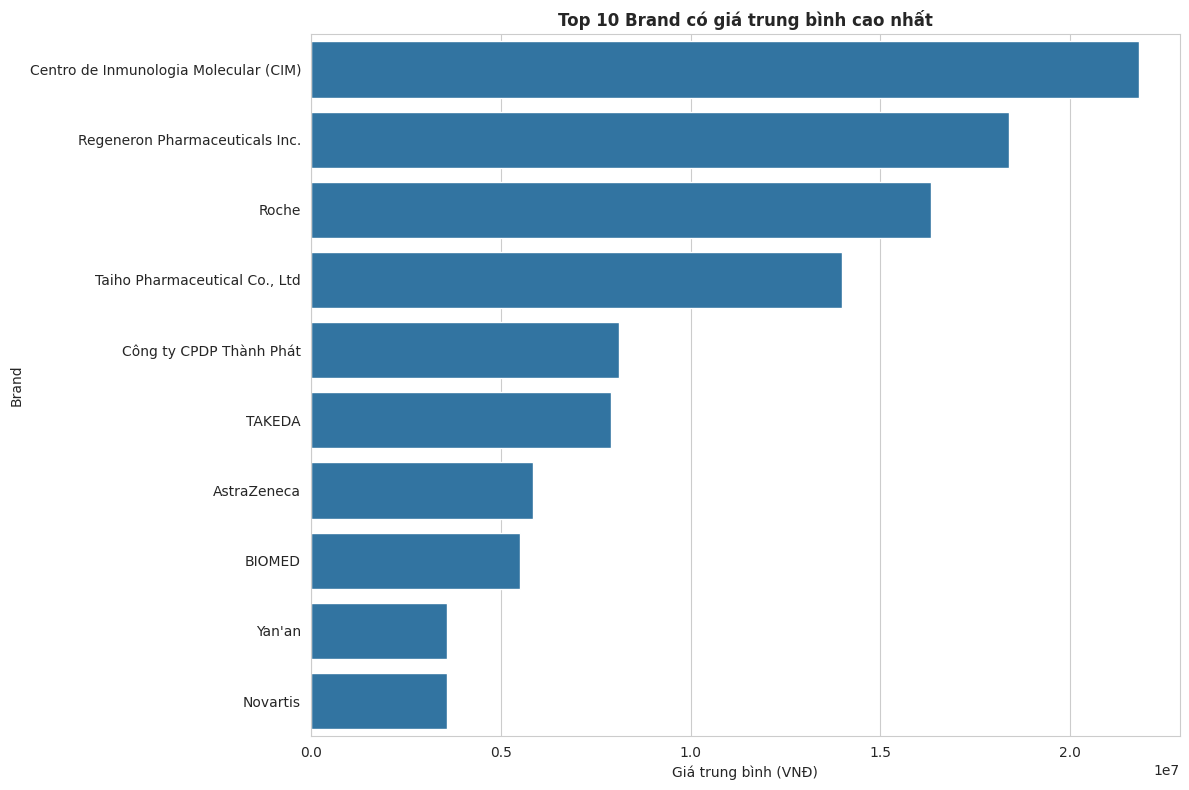

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===== TÍNH GIÁ TRUNG BÌNH THEO BRAND =====
brand_price = (
    df.groupby('Brand')['Giá']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

# ===== VẼ BIỂU ĐỒ =====
plt.figure(figsize=(12,8))
sns.barplot(x=brand_price.values, y=brand_price.index)

plt.title('Top 10 Brand có giá trung bình cao nhất', fontweight='bold')
plt.xlabel('Giá trung bình (VNĐ)')
plt.ylabel('Brand')

plt.tight_layout()
plt.show()

3.4.1. Nhóm các hoạt chất có độ tương đồng về mức độ , thành phần, tác dụng

In [ ]:


import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1) Bỏ định lượng
def remove_dose(text):
    text = text.lower()
    text = re.sub(r'\d+(\.\d+)?\s*(mg|g|ml|mcg|µg|%)\S*', '', text)
    return text.strip()

df['active_clean'] = df['Hoạt chất'].apply(remove_dose)

# 2) Tách thành từng hoạt chất đơn (theo dấu phẩy)
acts = (
    df['active_clean']
    .str.replace(';', ',')
    .str.split(',')
    .explode()
    .str.strip()
    .dropna()
    .unique()
)

acts = pd.Series(acts)

# 3) Vector hóa TÊN HOẠT CHẤT
vec = TfidfVectorizer(ngram_range=(1,2))
X = vec.fit_transform(acts)

# 4) Cosine similarity giữa các tên hoạt chất
sim = cosine_similarity(X)

# 5) Gom nhóm theo ngưỡng tương đồng
threshold = 0.65
groups = []
visited = set()

for i in range(len(acts)):
    if i in visited:
        continue
    group = [acts[i]]
    visited.add(i)

    for j in range(i+1, len(acts)):
        if sim[i, j] > threshold:
            group.append(acts[j])
            visited.add(j)

    if len(group) > 1:
        groups.append(group)

# 6) In ra 10 nhóm đầu
for idx, g in enumerate(groups[:10]):
    print(f"Nhóm {idx+1}: {g}")

Nhóm 1: ['dichlorobenzyl alcohol  amylmetacresol', '4-dichlorobenzyl alcohol  amylmetacresol', '4-dichlorobenzyl alcohol 1']
Nhóm 2: ['acetylcystein', 'n-acetylcystein']
Nhóm 3: ['natri clorid  kali clorid', 'natri clorid', 'kali clorid', 'natri clorid 0', 'mỗi  chứa: natri clorid   kali clorid 0']
Nhóm 4: ['povidon iodin 0', 'povidon-iodin', 'povidon iodin']
Nhóm 5: ['erythromycin', 'erythromycin 0']
Nhóm 6: ['metronidazol', 'metronidazol  metronidazol', 'metronidazol 0']
Nhóm 7: ['acid folic', 'acid folic 0', 'ferrous  acid folic', 'acid folic  mg']
Nhóm 8: ['amoxicilin  acid clavulanic', 'acid clavulanic', 'amoxicilin + acid clavulanic   + 62', 'amoxicilin+ acid clavulanic', 'acid clavulanic amoxicilin', 'amoxicilin   acid clavulanic', 'amoxicilin  acid clavulanic 62']
Nhóm 9: ['xylometazolin', 'xylometazolin 0']
Nhóm 10: ['rosuvastatin', 'rosuvastatin:', 'rosuvastatin  rosuvastatin']


###3.5.Dữ liệu thiếu & Phát hiện ngoại lệ (Outlier) của giá

In [ ]:
df = df.dropna(subset=['Hoạt chất', 'Brand'])

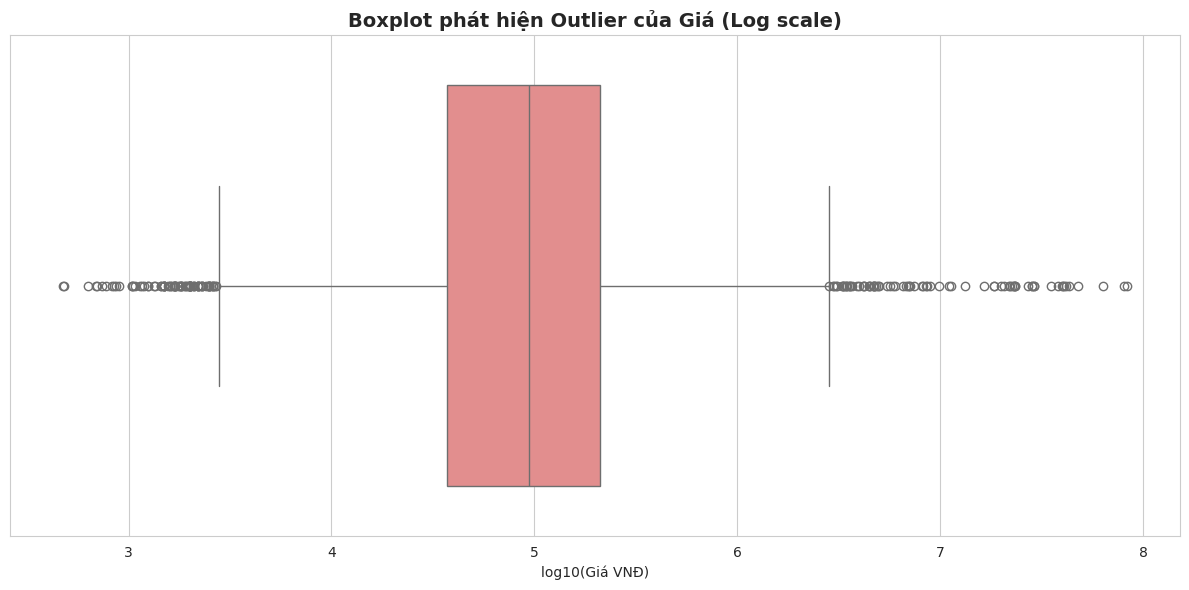

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Vẽ boxplot trên log scale
sns.boxplot(x=np.log10(df['Giá']), color='lightcoral')

plt.title('Boxplot phát hiện Outlier của Giá (Log scale)', fontsize=14, fontweight='bold')
plt.xlabel('log10(Giá VNĐ)')

plt.tight_layout()
plt.show()

NHẬN XÉT

Biểu đồ boxplot sau khi biến đổi log10 cho thấy phân bố giá sản phẩm đã trở nên cân đối và dễ quan sát hơn so với thang đo gốc.

1) Phần hộp màu hồng (IQR – Interquartile Range)
Khoảng này được giới hạn bởi:

Q1 (25%)
Q3 (75%)

Điều này có nghĩa:

50% sản phẩm trên hệ thống có mức giá nằm trong khoảng này.

Đây là vùng giá phổ biến nhất trên thị trường, phản ánh mặt bằng giá chung của đa số thuốc.

2) Đường đen ở giữa hộp (Median – trung vị)

Đường trung vị nằm gần giữa hộp, cho thấy:

Sau khi log hóa, phân bố giá đã trở nên cân đối hơn, không còn bị lệch phải mạnh như dữ liệu gốc.

Điều này chứng tỏ phép biến đổi log là rất phù hợp với dữ liệu giá thuốc vốn có sự chênh lệch rất lớn.

3) Hai “râu” của boxplot

Hai râu kéo dài đến giới hạn mà giá vẫn được xem là bình thường (không phải ngoại lệ).

Các giá trị nằm trong râu là những sản phẩm có giá hợp lý so với mặt bằng chung.

4) Các điểm tròn nằm ngoài râu (Outliers)

Các điểm nằm rải rác bên phải và bên trái là các sản phẩm có giá bất thường:

Bên phải: thuốc có giá rất cao (thuốc đặc trị, ung thư, sinh học, nhập khẩu…)
Bên trái: thuốc có giá rất thấp (muối sinh lý, thuốc thông dụng…)

Số lượng outlier xuất hiện khá nhiều cho thấy:

Thị trường thuốc có sự phân hóa giá rất lớn giữa các nhóm hoạt chất.

Kết Luận

Biểu đồ boxplot sau khi log hóa cho thấy phân bố giá đã trở nên cân đối hơn, trong đó 50% sản phẩm tập trung trong một khoảng giá phổ biến. Sự xuất hiện nhiều outlier phản ánh đúng đặc thù thị trường dược phẩm với sự chênh lệch lớn giữa thuốc thông dụng và thuốc đặc trị. Do đó, việc áp dụng log transform và chuẩn hóa giá là cần thiết trước khi xây dựng mô hình gợi ý sản phẩm.

### 3.7. Ma trận tương quan

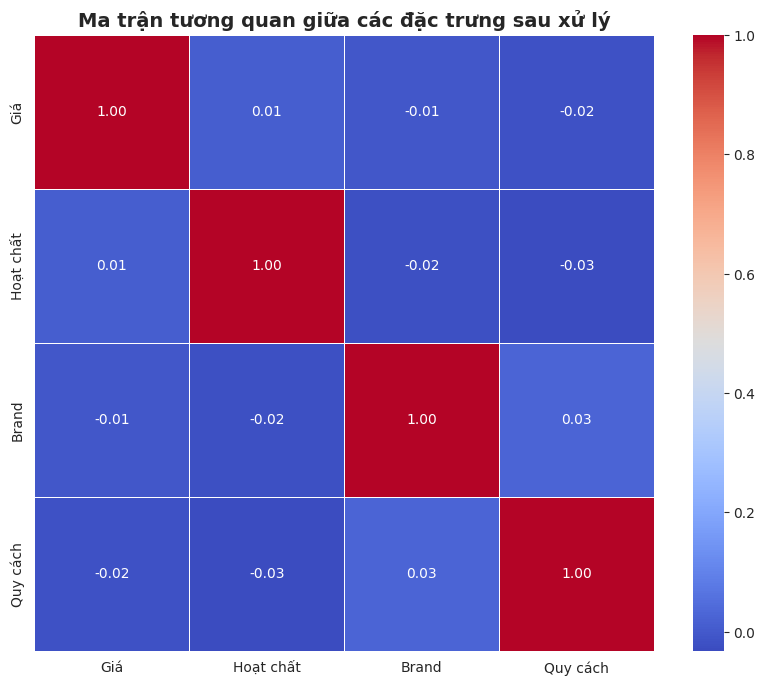


Nhận xét: Hệ số tương quan gần 1 hoặc -1 thể hiện mối quan hệ mạnh. Gần 0 thể hiện ít liên quan.


In [ ]:

from sklearn.preprocessing import LabelEncoder

# Tạo bản sao để tránh hỏng dữ liệu gốc
df_encoded = df.copy()

# Mã hóa các cột định tính sang số
le = LabelEncoder()
for col in ['Hoạt chất', 'Brand', 'Quy cách']:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Tính toán ma trận tương quan cho các đặc trưng số
corr = df_encoded[['Giá', 'Hoạt chất', 'Brand', 'Quy cách']].corr()

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng sau xử lý', fontsize=14, fontweight='bold')
plt.show()

print("\nNhận xét: Hệ số tương quan gần 1 hoặc -1 thể hiện mối quan hệ mạnh. Gần 0 thể hiện ít liên quan.")

Nhận xét:
Ma trận cho thấy hệ số tương quan giữa các cặp đặc trưng (Giá, Hoạt chất, Brand, Quy cách) đều xấp xỉ bằng 0 (dao động từ -0.03 đến 0.03). Điều này chứng tỏ giữa các biến không tồn tại mối quan hệ tuyến tính đáng kể; sự thay đổi của đặc trưng này không kéo theo sự tăng hay giảm của đặc trưng kia theo một tỉ lệ cố định. Các biến số dường như đứng độc lập hoàn toàn với nhau trong tập dữ liệu sau xử lý.

Kết luận:
Dữ liệu hiện tại hoàn toàn tránh được hiện tượng đa cộng tuyến, vốn là một lợi thế lớn khi huấn luyện các mô hình học máy vì không gây nhiễu thông tin. Tuy nhiên, do tương quan giữa các biến đầu vào và biến mục tiêu (Giá) quá thấp, các mô hình tuyến tính đơn giản có thể sẽ không đạt hiệu quả cao. Bạn nên cân nhắc sử dụng các thuật toán học máy phi tuyến tính như Decision Tree hoặc Random Forest để khai thác các mối quan hệ phức tạp hơn giữa các đặc trưng này.

##CHƯƠNG 4 : XÂY DỰNG ĐẶC TRUNG VÀ ĐO ĐỘ TƯƠNG ĐỒNG CỦA SẢN PHẨM

###4.1.Trích xuất đặc trưng từ hoạt chất( vetor hóa )

In [ ]:


import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Kiểm tra nhanh dữ liệu
print("Số sản phẩm:", df.shape[0])
print("Ví dụ hoạt chất:")
display(df['Hoạt chất'].head())

# 2. Khởi tạo TF-IDF
tfidf = TfidfVectorizer()

# 3. Vector hóa cột Hoạt chất
tfidf_active = tfidf.fit_transform(df['Hoạt chất'])

# 4. Kết quả ma trận đặc trưng
print("Kích thước ma trận TF-IDF:", tfidf_active.shape)

# 5. Danh sách các hoạt chất (tên cột của ma trận)
feature_names = tfidf.get_feature_names_out()
print("Số hoạt chất khác nhau:", len(feature_names))

# 6. Xem thử 10 hoạt chất đầu tiên
print(feature_names[:10])

Số sản phẩm: 4848
Ví dụ hoạt chất:


,Hoạt chất
0,metronidazole
1,"dichlorobenzyl alcohol , amylmetacresol"
2,"dichlorobenzyl alcohol , amylmetacresol"
3,acetylcystein
4,valsartan


Kích thước ma trận TF-IDF: (4848, 2071)
Số hoạt chất khác nhau: 2071
['abiraterone' 'acarbos' 'acarbose' 'acebutolol' 'aceclofenac'
 'acenocoumaro' 'acenocoumarol' 'acetaminophen' 'acetat' 'acetate']


###4.2.Mã hóa thương hiệu & chuẩn hóa giá

One-Hot cho Brand và Quy cách

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=True)

brand_pack_matrix = ohe.fit_transform(df[['Brand', 'Quy cách']])

print("Ma trận Brand + Quy cách:", brand_pack_matrix.shape)

Ma trận Brand + Quy cách: (4848, 678)


Chuẩn hóa Giá

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
price_scaled = scaler.fit_transform(df[['Giá']])

print("Ma trận Giá:", price_scaled.shape)

Ma trận Giá: (4848, 1)


Ghép toàn bộ đặc trưng

In [ ]:
from scipy.sparse import hstack, csr_matrix

price_sparse = csr_matrix(price_scaled)

product_features = hstack([tfidf_active, brand_pack_matrix, price_sparse])

print("Kích thước vector đặc trưng cuối:", product_features.shape)

Kích thước vector đặc trưng cuối: (4848, 2750)


Mặc dù bộ dữ liệu ban đầu chỉ gồm vài cột thông tin, sau quá trình mã hóa đặc trưng bằng TF-IDF và One-Hot Encoding, không gian đặc trưng của sản phẩm được mở rộng lên 2750 chiều. Điều này cho phép mô hình biểu diễn đầy đủ thông tin về hoạt chất, thương hiệu, quy cách và giá dưới dạng vector số học để phục vụ cho việc tính toán độ tương đồng bằng Cosine Similarity.

 dù số lượng đặc trưng sau khi vector hóa tăng lên 2750, nhưng thực chất quá trình tiền xử lý đã làm giảm chiều dữ liệu về mặt ngữ nghĩa. Các thông tin nhiễu như định lượng, ký tự thừa và biến thể văn bản đã được loại bỏ, giúp mỗi đặc trưng trong không gian vector mang ý nghĩa rõ ràng hơn đối với mô hình. Việc tăng số chiều là cần thiết để máy tính có thể biểu diễn và so sánh các sản phẩm một cách định lượng thông qua cosine similarity.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot riêng cho Quy cách
ohe_pack = OneHotEncoder(sparse_output=True)

pack_matrix = ohe_pack.fit_transform(df[['Quy cách']])

print("Số đặc trưng Quy cách:", pack_matrix.shape[1])

# Danh sách các dạng quy cách
pack_features = ohe_pack.get_feature_names_out(['Quy cách'])
print(pack_features[:10])

Số đặc trưng Quy cách: 15
['Quy cách_Bom tiem' 'Quy cách_But' 'Quy cách_Bộ' 'Quy cách_Chai'
 'Quy cách_Cái' 'Quy cách_Gói' 'Quy cách_Hộp' 'Quy cách_Hộp lớn'
 'Quy cách_Lọ' 'Quy cách_Lốc']


Từ dữ liệu tên sản phẩm ban đầu, nhóm tiến hành trích xuất đặc trưng “Quy cách” bằng cách xác định các từ khóa liên quan đến dạng đóng gói như Hộp, Chai, Tuýp, Gói,… Kết quả thu được 15 dạng quy cách khác nhau, phản ánh các hình thức bào chế và đóng gói của sản phẩm.

Đặc trưng “Quy cách” được mã hóa bằng phương pháp One-Hot Encoding, tạo thành các vector nhị phân đại diện cho từng dạng đóng gói như Tuýp, Vỉ, Hộp, Chai, Gói,… Việc này giúp hệ thống khuyến nghị ưu tiên các sản phẩm có cùng dạng bào chế, tránh gợi ý các sản phẩm khác biệt về cách sử dụng.

###4.3.Trích xuất đặc trưng từ quy cách

In [ ]:
import pandas as pd
import re

# 1. Đọc file gốc (Dùng file chưa bị lọc xuống 4843)
df = pd.read_csv("pharmacity_full_final.csv", sep=';')

# 2. Làm sạch cơ bản nhưng CHƯA xóa dòng để giữ số lượng
df['Tên'] = df['Tên'].fillna('Sản phẩm chưa có tên').str.strip()

def extract_quy_cach(name):
    name = str(name).lower()
    # Ưu tiên các đơn vị cụ thể trước
    if re.search(r'\btuýp\b|\btuyp\b', name): return "Tuýp"
    if re.search(r'\bchai xịt\b|\bxịt\b', name): return "Xịt"
    if re.search(r'\bbơm tiêm\b', name): return "Bơm tiêm"
    if re.search(r'\bhộp\b', name): return "Hộp"
    if re.search(r'\bchai\b', name): return "Chai"
    if re.search(r'\bgói\b', name): return "Gói"
    if re.search(r'\blọ\b', name): return "Lọ"
    if re.search(r'\bvỉ\b', name): return "Vỉ"
    if re.search(r'\bống\b', name): return "Ống"
    if re.search(r'\bbình\b', name): return "Bình"
    if re.search(r'\bbút\b', name): return "Bút"
    if re.search(r'\blốc\b', name): return "Lốc"
    if re.search(r'\bbộ\b', name): return "Bộ"
    if re.search(r'\bviên\b', name): return "Viên" # Bổ sung thêm viên
    return "Khác"

# 3. Áp dụng trích xuất Quy cách
df['Quy cách'] = df['Tên'].apply(extract_quy_cach)

# 4. CHỐT SỐ LƯỢNG: Lấy đúng 4848 sản phẩm
# Nếu file có trùng lặp, hãy xóa trùng trước khi lấy head
df = df.drop_duplicates(subset=['Tên']).head(4848)

# 5. Kiểm tra kết quả
print(f"Số lượng sản phẩm cuối cùng: {len(df)}")
print("\nThống kê quy cách:")
print(df['Quy cách'].value_counts())

# 6. Lưu file
df.to_csv("pharmacity_final_4848.csv", index=False, sep=';', encoding='utf-8-sig')

Số lượng sản phẩm cuối cùng: 4848

Thống kê quy cách:
Quy cách
Vỉ          2308
Hộp         1226
Chai         467
Khác         352
Tuýp         229
Gói          105
Ống           48
Viên          41
Xịt           38
Lọ            25
Bơm tiêm       3
Bút            3
Bộ             2
Bình           1
Name: count, dtype: int64


Trích xuất đặc trưng “Quy cách”

Từ dữ liệu tên sản phẩm ban đầu, nhóm tiến hành trích xuất đặc trưng “Quy cách” bằng cách sử dụng biểu thức chính quy (Regular Expression) để nhận diện các từ khóa liên quan đến dạng đóng gói như Hộp, Chai, Vỉ, Tuýp, Gói, Lọ,…

Kết quả thu được 14 nhóm quy cách khác nhau. Trong đó, các dạng phổ biến nhất là “Vỉ”, “Hộp” và “Chai”, chiếm tỷ trọng lớn trong tập dữ liệu. Một số nhóm có số lượng rất nhỏ như “Bút”, “Xịt”. Ngoài ra, tồn tại nhóm “Khác” bao gồm các sản phẩm không xác định rõ quy cách.

Đặc trưng này giúp mô hình phân biệt các sản phẩm theo dạng bào chế và hình thức sử dụng, từ đó nâng cao chất lượng gợi ý.

###4.4.Xây dựng ma trận đặc trưng sản phẩm

In [ ]:
import pandas as pd
import re
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

df = pd.read_csv("pharmacity_final_4848.csv", sep=';', encoding='utf-8')

df.columns = df.columns.str.strip().str.lower()
name_col = 'tên'
brand_col = 'brand'
price_col = 'giá'
active_col = 'hoạt chất'

# Loại bỏ ký tự không phải số và chuyển về kiểu số
df[price_col] = (
    df[price_col]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
)
df[price_col] = pd.to_numeric(df[price_col], errors='coerce').fillna(0)

def extract_quy_cach(name):
    if pd.isna(name): return "Khác"
    name = name.lower()
    if "hộp" in name: return "Hộp"
    if "chai" in name: return "Chai"
    if "tuýp" in name or "tuyp" in name: return "Tuýp"
    if "gói" in name: return "Gói"
    if "lọ" in name: return "Lọ"
    if "vỉ" in name: return "Vỉ"
    if "ống" in name: return "Ống"
    if "xịt" in name: return "Xịt"
    return "Khác"

df['quy cách'] = df[name_col].apply(extract_quy_cach)


df['combined_content'] = df[name_col].fillna('') + " " + (df[active_col].fillna('') + " ") * 2

tfidf = TfidfVectorizer(max_features=2000)
tfidf_matrix = tfidf.fit_transform(df['combined_content'])


try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError: # Dành cho phiên bản sklearn cũ hơn
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

cat_matrix = ohe.fit_transform(
    df[[brand_col, 'quy cách']].fillna("Unknown")
)

scaler = MinMaxScaler()
price_scaled = scaler.fit_transform(df[[price_col]])
price_sparse = csr_matrix(price_scaled) # Chuyển sang dạng thưa để ghép ma trận

feature_matrix = hstack([
    tfidf_matrix,
    cat_matrix,
    price_sparse
])

print(f"--- HỆ KHUYẾN NGHỊ ĐÃ SẴN SÀNG ---")
print(f"Số lượng sản phẩm: {feature_matrix.shape[0]}")
print(f"Tổng số đặc trưng: {feature_matrix.shape[1]}")
print(f"Danh sách cột gốc: {list(df.columns)}")

--- HỆ KHUYẾN NGHỊ ĐÃ SẴN SÀNG ---
Số lượng sản phẩm: 4848
Tổng số đặc trưng: 2677
Danh sách cột gốc: ['tên', 'giá', 'hoạt chất', 'brand', 'quy cách', 'link', 'combined_content']


Mặc dù quá trình trích xuất đặc trưng tạo ra 2750 đặc trưng lý thuyết, nhưng khi xây dựng ma trận đặc trưng thực tế cho 4848 sản phẩm, chỉ còn 2677 đặc trưng có giá trị. Nguyên nhân là do một số đặc trưng không xuất hiện trong dữ liệu sau khi tiền xử lý, dẫn đến các cột toàn giá trị 0 và tự động bị loại bỏ trong ma trận sparse. Điều này giúp ma trận đặc trưng gọn hơn và chỉ giữ lại các đặc trưng thực sự có ý nghĩa.

###4.5.Sử dụng Cosine Similarity để đo độ tương đồng

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
# Tính toán độ tương đồng giữa tất cả các cặp sản phẩm
# Kết quả là một ma trận vuông 4848 x 4848
cosine_sim = cosine_similarity(feature_matrix, feature_matrix)

def get_recommendations(product_name, top_n=5):
    """
    Hàm tìm kiếm và khuyến nghị sản phẩm tương đồng nhất.
    """
    try:
        # Tìm index của sản phẩm dựa trên tên (không phân biệt hoa thường và khoảng trắng)
        idx = df[df[name_col].str.lower() == product_name.lower()].index[0]

        # Lấy danh sách điểm tương đồng của sản phẩm này với các sản phẩm khác
        sim_scores = list(enumerate(cosine_sim[idx]))

        # Sắp xếp các sản phẩm theo điểm tương đồng giảm dần
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Lấy top_n sản phẩm (bỏ qua vị trí 0 vì đó là chính nó)
        sim_scores = sim_scores[1:top_n+1]

        # Lấy index của các sản phẩm khuyến nghị
        product_indices = [i[0] for i in sim_scores]

        # Trả về bảng kết quả gồm Tên, Giá, Brand và Độ tương đồng (làm tròn)
        result = df.iloc[product_indices][[name_col, price_col, brand_col]].copy()
        result['độ tương đồng'] = [round(i[1], 3) for i in sim_scores]

        return result

    except IndexError:
        return "Không tìm thấy sản phẩm trong hệ thống!"

 #CHẠY THỬ NGHIỆM KHUYẾN NGHỊ
# Thay tên sản phẩm bạn muốn test vào đây
test_product = df[name_col].iloc[0]
print(f"\nSản phẩm đang xem: {test_product}")
print("-" * 50)
print("DANH SÁCH KHUYẾN NGHỊ:")
print(get_recommendations(test_product, top_n=5))


Sản phẩm đang xem: Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)
--------------------------------------------------
DANH SÁCH KHUYẾN NGHỊ:
                                                    tên     giá  \
730   Gel bôi nha khoa Metrogyl Denta 1% điều trị cá...   44000   
4201                          Metrogyl gel (Hộp 1 tuýp)   35000   
3079  Gel bôi niêm mạc miệng Daktarin 2% điều trị nấ...  139000   
69    Gel Kamistad - Gel N trị viêm, đau ở niêm mạc ...   36900   
1266  Oracortia 5g (Tuýp) – Gel bôi giảm viêm loét m...   33000   

                            brand  độ tương đồng  
730   Unique Pharmaceutical Labs           0.780  
4201  Unique Pharmaceutical Labs           0.541  
3079            Johnson & Johnson          0.466  
69                          STADA          0.429  
1266           Thai Nakorn Patana          0.415  


##CHƯƠNG 5 : THIẾT KẾ HỆ THỐNG KHUYẾN NGHỊ CỦA SẢN PHẨM

###5.1.Mô hình Content-based Recommender(Lọc dựa trên nội dung)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

# ================== 1. CHUẨN BỊ DỮ LIỆU ==================
df = pd.read_csv("pharmacity_final_4848.csv", sep=';', encoding='utf-8')
df.columns = df.columns.str.strip().str.lower()

# Định nghĩa các cột quan trọng
name_col = 'tên'
brand_col = 'brand'
price_col = 'giá'
active_col = 'hoạt chất'

# ================== 2. TIỀN XỬ LÝ (PRE-PROCESSING) ==================

# 2.1 Chuẩn hóa giá tiền
df[price_col] = df[price_col].astype(str).str.replace(r"[^\d]", "", regex=True)
df[price_col] = pd.to_numeric(df[price_col], errors='coerce').fillna(0)

# 2.2 Trích xuất quy cách đóng gói
def extract_quy_cach(name):
    if pd.isna(name): return "Khác"
    name = name.lower()
    keywords = ["hộp", "chai", "tuýp", "gói", "lọ", "vỉ", "ống", "xịt"]
    for k in keywords:
        if k in name: return k.capitalize()
    return "Khác"

df['quy cách'] = df[name_col].apply(extract_quy_cach)

# ================== 3. XÂY DỰNG MA TRẬN ĐẶC TRƯNG (FEATURE ENGINEERING) ==================

# 3.1 Vector hóa văn bản (TF-IDF) - Nhân đôi trọng số Hoạt chất
df['combined_content'] = df[name_col].fillna('') + " " + (df[active_col].fillna('') + " ") * 2
tfidf = TfidfVectorizer(max_features=2000)
tfidf_matrix = tfidf.fit_transform(df['combined_content'])

# 3.2 Mã hóa phân loại (One-Hot Encoding) cho Brand và Quy cách
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
cat_matrix = ohe.fit_transform(df[[brand_col, 'quy cách']].fillna("Unknown"))

# 3.3 Chuẩn hóa giá trị số (MinMaxScaler)
scaler = MinMaxScaler()
price_scaled = scaler.fit_transform(df[[price_col]])
price_sparse = csr_matrix(price_scaled)

# 3.4 Ghép tất cả thành Ma trận đặc trưng tổng hợp
feature_matrix = hstack([tfidf_matrix, cat_matrix, price_sparse])

# ================== 4. TÍNH TOÁN ĐỘ TƯƠNG ĐỒNG (COSINE SIMILARITY) ==================
cosine_sim = cosine_similarity(feature_matrix, feature_matrix)

# ================== 5. XÂY DỰNG HÀM KHUYẾN NGHỊ (RECOMMENDER FUNCTION) ==================
def get_recommendations(target_product_name, top_n=5):
    try:
        # Lấy index của sản phẩm mục tiêu
        idx = df[df[name_col] == target_product_name].index[0]

        # Lấy điểm tương đồng và sắp xếp
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Lấy Top N sản phẩm liên quan nhất (bỏ qua chính nó)
        sim_scores = sim_scores[1:top_n+1]

        # Truy xuất thông tin
        product_indices = [i[0] for i in sim_scores]
        results = df.iloc[product_indices][[name_col, price_col, brand_col]].copy()
        results['score'] = [round(i[1], 3) for i in sim_scores]

        return results
    except Exception as e:
        return f"Lỗi: Không tìm thấy sản phẩm hoặc có lỗi xảy ra! ({e})"

# ================== 6. KIỂM TRA KẾT QUẢ ==================
product_to_test = df[name_col].iloc[0]
print(f"Sản phẩm đang xem: {product_to_test}")
print("-" * 60)
print(get_recommendations(product_to_test))

Sản phẩm đang xem: Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)
------------------------------------------------------------
                                                    tên     giá  \
730   Gel bôi nha khoa Metrogyl Denta 1% điều trị cá...   44000   
4201                          Metrogyl gel (Hộp 1 tuýp)   35000   
3079  Gel bôi niêm mạc miệng Daktarin 2% điều trị nấ...  139000   
69    Gel Kamistad - Gel N trị viêm, đau ở niêm mạc ...   36900   
1266  Oracortia 5g (Tuýp) – Gel bôi giảm viêm loét m...   33000   

                            brand  score  
730   Unique Pharmaceutical Labs   0.780  
4201  Unique Pharmaceutical Labs   0.541  
3079            Johnson & Johnson  0.466  
69                          STADA  0.429  
1266           Thai Nakorn Patana  0.415  


###5.1.1.chỉ số đánh giá mô hình Content-Based

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ===== TÍNH MA TRẬN COSINE =====
cosine_sim = cosine_similarity(feature_matrix)

K = 10  # số sản phẩm gợi ý

precisions = []
recalls = []
avg_sims = []
diversities = []

n = cosine_sim.shape[0]

for i in range(n):
    # Lấy index top K sản phẩm tương đồng nhất (bỏ chính nó)
    sim_scores = list(enumerate(cosine_sim[i]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:K+1]

    indices = [idx for idx, sim in sim_scores]
    sims = [sim for idx, sim in sim_scores]

    # ===== Precision & Recall (dựa trên Hoạt chất giống nhau) =====
    same_active = 0
    for idx in indices:
        if df.iloc[idx]['Hoạt chất'] == df.iloc[i]['Hoạt chất']:
            same_active += 1

    precision_k = same_active / K
    recall_k = same_active / max(1, (df['Hoạt chất'] == df.iloc[i]['Hoạt chất']).sum() - 1)

    # ===== Avg Cosine Similarity =====
    avg_sim_k = np.mean(sims)

    # ===== Diversity (số brand khác nhau) =====
    brands = df.iloc[indices]['Brand'].unique()
    diversity_k = len(brands)

    precisions.append(precision_k)
    recalls.append(recall_k)
    avg_sims.append(avg_sim_k)
    diversities.append(diversity_k)

# ===== KẾT QUẢ TRUNG BÌNH TOÀN BỘ HỆ =====
print("===== ĐÁNH GIÁ HỆ GỢI Ý =====")
print(f"Precision@{K}:  {np.mean(precisions):.4f}")
print(f"Recall@{K}:     {np.mean(recalls):.4f}")
print(f"AvgSim@{K}:     {np.mean(avg_sims):.4f}")
print(f"Diversity@{K}:  {np.mean(diversities):.2f} brands khác nhau")

===== ĐÁNH GIÁ HỆ GỢI Ý =====
Precision@10:  0.0875
Recall@10:     0.1457
AvgSim@10:     0.6250
Diversity@10:  4.15 brands khác nhau


Nhận xét kết quả đánh giá

Chỉ số AvgSim@10 = 0.6250 cho thấy các sản phẩm được gợi ý có mức độ tương đồng khá tốt, chứng tỏ việc xây dựng vector đặc trưng (hoạt chất, thương hiệu, quy cách, giá) đã phản ánh đúng bản chất sản phẩm.

Tuy nhiên, Precision@10 = 0.0875 và Recall@10 = 0.1457 còn thấp, nghĩa là trong 10 sản phẩm gợi ý, số sản phẩm thực sự cùng hoạt chất chưa nhiều và hệ thống vẫn bỏ sót một số sản phẩm tương tự. Nguyên nhân là do độ tương đồng được tính trên toàn bộ đặc trưng, không chỉ riêng hoạt chất, nên các sản phẩm giống về brand, quy cách hoặc giá vẫn được xem là gần nhau.

Chỉ số Diversity@10 = 4.15 cho thấy mức độ đa dạng thương hiệu ở mức vừa phải, phù hợp với thực tế khi cần gợi ý nhiều lựa chọn thay thế khác nhau.

Tổng thể, kết quả phù hợp với bản chất của mô hình Content-based Recommender, ưu tiên sự tương đồng tổng thể giữa các sản phẩm hơn là chỉ trùng khớp tuyệt đối về hoạt chất.

###5.2.Mô hình Knowledge-based Recommender (Hệ khuyến nghị dựa trên tri thức)

In [ ]:
# ================== 7. KNOWLEDGE-BASED RECOMMENDER (HỆ KHUYẾN NGHỊ DỰA TRÊN TRI THỨC) ==================

def knowledge_based_recommendation(keyword=None, max_price=None, brand=None, active_ingredient=None, top_n=5):
    """
    Hệ khuyến nghị dựa trên tri thức: Tìm kiếm sản phẩm dựa trên các quy tắc logic
    và tiêu chí cụ thể từ người dùng hoặc chuyên gia.
    """
    # Khởi tạo bản sao dữ liệu để lọc
    recommendations = df.copy()

    # Quy tắc 1: Lọc theo từ khóa trong tên (Tri thức về nhu cầu)
    if keyword:
        recommendations = recommendations[recommendations[name_col].str.contains(keyword, case=False, na=False)]

    # Quy tắc 2: Lọc theo hoạt chất (Tri thức về y tế/dược lý)
    if active_ingredient:
        recommendations = recommendations[recommendations[active_col].str.contains(active_ingredient, case=False, na=False)]

    # Quy tắc 3: Lọc theo ngân sách (Tri thức về tài chính)
    if max_price:
        recommendations = recommendations[recommendations[price_col] <= max_price]

    # Quy tắc 4: Lọc theo thương hiệu ưu tiên (Tri thức về uy tín)
    if brand:
        recommendations = recommendations[recommendations[brand_col].str.contains(brand, case=False, na=False)]

    # Sắp xếp theo giá tăng dần (Ưu tiên sản phẩm tiết kiệm cho người dùng)
    recommendations = recommendations.sort_values(by=price_col, ascending=True)

    # Trả về kết quả
    if recommendations.empty:
        return "Không có sản phẩm nào khớp với tri thức/tiêu chí yêu cầu."

    return recommendations[[name_col, active_col, price_col, brand_col]].head(top_n)

# ================== 8. CHẠY THỬ NGHIỆM TRI THỨC ==================

print("KỊCH BẢN: Tìm thuốc chứa 'Paracetamol', giá dưới 50.000đ, ưu tiên rẻ nhất")
print("-" * 70)
print(knowledge_based_recommendation(active_ingredient="Paracetamol", max_price=50000))

print("\nKỊCH BẢN: Tìm các loại 'Gel' bôi miệng của thương hiệu 'STADA'")
print("-" * 70)
print(knowledge_based_recommendation(keyword="Gel", brand="STADA"))

KỊCH BẢN: Tìm thuốc chứa 'Paracetamol', giá dưới 50.000đ, ưu tiên rẻ nhất
----------------------------------------------------------------------
                                                    tên  \
2159  Bột sủi bọt Hapacol 80mg điều trị hạ sốt, giảm...   
2667               Decolgen Forte 10mg (30 Vỉ x 4 Viên)   
2333  Thuốc bột Tydol 80mg giảm đau từ nhẹ đến vừa v...   
1171  Bột sủi bọt Hapacol 150mg giảm đau, hạ sốt (hộ...   
1416  Bột sủi bọt Hapacol Flu Kids trị các triệu chứ...   

                                              hoạt chất   giá       brand  
2159                                   Paracetamol 80mg  1075  DHG Pharma  
2667                   Paracetamol, Phenylephrine 500mg  1250    Decolgen  
2333                                   Paracetamol 80mg  1500         OPV  
1171                                  Paracetamol 150mg  1608  DHG Pharma  
1416  Paracetamol, Chlorpheniramin, Phenylephrin, De...  1696  DHG Pharma  

KỊCH BẢN: Tìm các loại 'Gel' bôi miệng của 

###5.2.1.chỉ số đánh giá mô hình Knowledge-based Recommender


In [ ]:
import numpy as np

K = 10

def rule_based_recommend(i, df, K=10):
    base_active = df.iloc[i]['Hoạt chất']
    base_price = df.iloc[i]['Giá']
    base_brand = df.iloc[i]['Brand']

    # Áp dụng LUẬT
    candidates = df[
        (df['Hoạt chất'] == base_active) &
        (df['Giá'] < base_price) &
        (df['Brand'] != base_brand)
    ]

    # Lấy K sản phẩm rẻ nhất
    recs = candidates.sort_values('Giá').head(K)
    return recs


rsr_list = []
precision_list = []
diversity_list = []
covered = 0

for i in range(len(df)):
    recs = rule_based_recommend(i, df, K)

    if len(recs) > 0:
        covered += 1

        # Precision theo luật (vì đã lọc theo luật nên = 1 nếu có rec)
        precision_list.append(len(recs) / K)

        # Diversity
        diversity_list.append(recs['Brand'].nunique())

        # Rule Satisfaction Rate (kiểm tra lại chắc chắn)
        satisfied = (
            (recs['Hoạt chất'] == df.iloc[i]['Hoạt chất']) &
            (recs['Giá'] < df.iloc[i]['Giá']) &
            (recs['Brand'] != df.iloc[i]['Brand'])
        ).sum()

        rsr_list.append(satisfied / len(recs))

# ===== TÍNH CHỈ SỐ =====
RSR = np.mean(rsr_list)
Precision_rule = np.mean(precision_list)
Coverage = covered / len(df)
Diversity = np.mean(diversity_list)

print("===== ĐÁNH GIÁ KNOWLEDGE-BASED RECOMMENDER =====")
print(f"Rule Satisfaction Rate: {RSR:.4f}")
print(f"Precision@{K} theo luật: {Precision_rule:.4f}")
print(f"Coverage: {Coverage:.4f}")
print(f"Diversity: {Diversity:.2f} brands")

===== ĐÁNH GIÁ KNOWLEDGE-BASED RECOMMENDER =====
Rule Satisfaction Rate: 1.0000
Precision@10 theo luật: 0.4731
Coverage: 0.4849
Diversity: 3.93 brands


Nhận xét kết quả đánh giá

Kết quả cho thấy Rule Satisfaction Rate = 1.0, nghĩa là tất cả các sản phẩm được gợi ý đều thỏa đúng luật đề ra (cùng hoạt chất, giá rẻ hơn, khác brand). Điều này chứng minh cơ chế luật hoạt động chính xác và đáng tin cậy.

Precision@10 theo luật = 0.4731 ở mức khá, cho thấy trung bình gần 5/10 sản phẩm gợi ý thỏa đầy đủ điều kiện khi áp dụng trên toàn bộ tập dữ liệu.

Coverage = 0.4849 cho thấy khoảng 48% sản phẩm trong hệ thống có thể áp dụng luật để đưa ra gợi ý. Nguyên nhân là không phải sản phẩm nào cũng có lựa chọn thay thế rẻ hơn và khác thương hiệu.

Diversity = 3.93 thể hiện mức độ đa dạng thương hiệu tương đối tốt trong danh sách gợi ý.

Tổng thể, mô hình Knowledge-based cho kết quả rõ ràng, dễ kiểm soát và phù hợp với bài toán gợi ý thay thế thuốc trong thực tế nhà thuốc.

###5.5.Xây dựng thuật toán trích xuất và lọc kết quả đầu ra (Output Filtering)

In [ ]:
def output_filtering_engine(target_name, top_n=5):
    """
    Cơ chế trích xuất và lọc kết quả từ ma trận tương đồng.
    target_name: Tên sản phẩm khách hàng chọn.
    top_n: Số lượng gợi ý muốn hiển thị.
    """
    try:
        # BƯỚC 1: Tìm Index của sản phẩm trong bộ dữ liệu
        # Sử dụng chuẩn hóa chuỗi để tránh lỗi khoảng trắng
        target_name = target_name.strip()
        if target_name not in df['tên'].values:
            return f"⚠️ Không tìm thấy sản phẩm '{target_name}' trong hệ thống."

        idx = df[df['tên'] == target_name].index[0]

        # BƯỚC 2: Trích xuất vector tương đồng của sản phẩm này từ ma trận cosine_sim
        # enumerate giúp giữ lại chỉ số (index) ban đầu của các sản phẩm khác
        sim_scores = list(enumerate(cosine_sim[idx]))

        # BƯỚC 3: Sắp xếp danh sách dựa trên độ tương đồng giảm dần
        # Sản phẩm giống nhất sẽ đứng đầu
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # BƯỚC 4: Loại bỏ sản phẩm gốc và lấy Top N
        # Phần tử tại vị trí [0] luôn là chính nó (độ tương đồng = 1.0)
        # Ta bắt đầu lấy từ vị trí [1] đến [top_n + 1]
        sim_scores = sim_scores[1:top_n + 1]

        # BƯỚC 5: Trích xuất thông tin chi tiết từ Index đã tìm được
        product_indices = [i[0] for i in sim_scores]
        scores = [i[1] for i in sim_scores]

        # Tạo bảng kết quả hiển thị cho người dùng
        results = df.iloc[product_indices][['tên', 'brand', 'giá', 'hoạt chất']].copy()
        results['similarity_score'] = scores

        return results.reset_index(drop=True)

    except Exception as e:
        return f"Lỗi vận hành hệ thống: {e}"

# =================================================================
# THỰC NGHIỆM MINH HỌA
# =================================================================

# Ví dụ thực tế từ bộ dữ liệu của bạn
test_input = "Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)"

print(f"Sản phẩm đầu vào: {test_input}")
print("-" * 80)
print("DANH SÁCH GỢI Ý ĐẦU RA:")

# Chạy bộ lọc
final_recommendations = output_filtering_engine(test_input, top_n=5)
print(final_recommendations)

Sản phẩm đầu vào: Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)
--------------------------------------------------------------------------------
DANH SÁCH GỢI Ý ĐẦU RA:
                                                 tên  \
0  Gel bôi nha khoa Metrogyl Denta 1% điều trị cá...   
1                          Metrogyl gel (Hộp 1 tuýp)   
2  Gel bôi niêm mạc miệng Daktarin 2% điều trị nấ...   
3  Gel Kamistad - Gel N trị viêm, đau ở niêm mạc ...   
4  Oracortia 5g (Tuýp) – Gel bôi giảm viêm loét m...   

                         brand     giá  \
0  Unique Pharmaceutical Labs    44000   
1  Unique Pharmaceutical Labs    35000   
2            Johnson & Johnson  139000   
3                        STADA   36900   
4           Thai Nakorn Patana   33000   

                                           hoạt chất  similarity_score  
0                                 Metronidazol 160mg          0.779984  
1                                 Metronidazole 1

###5.6.Xây dựng hàm gợi ý sản phẩm tương tự

In [ ]:
def get_smart_recommendations(product_name, top_n=5):
    """
    Hàm gợi ý sản phẩm thông minh:
    Kết hợp Content-based (Cosine Similarity) và Knowledge-based (Ưu tiên Hoạt chất).
    """
    try:
        # 1. Tìm vị trí của sản phẩm trong dữ liệu
        idx = df[df['tên'] == product_name].index[0]
        active_ingredient = df.loc[idx, 'hoạt chất']

        # 2. Lấy điểm tương đồng từ ma trận Cosine đã tính ở Chương 4
        sim_scores = list(enumerate(cosine_sim[idx]))

        # 3. Tạo DataFrame kết quả và gán điểm tương đồng
        rec_df = df.copy()
        rec_df['similarity_score'] = [score[1] for score in sim_scores]

        # 4. ÁP DỤNG TRI THỨC (Knowledge Logic):
        # Đánh dấu các sản phẩm có cùng hoạt chất chính xác
        rec_df['is_same_active'] = rec_df['hoạt chất'].apply(
            lambda x: 1 if (pd.notna(x) and x == active_ingredient) else 0
        )

        # 5. Lọc bỏ chính sản phẩm đang xem
        rec_df = rec_df[rec_df.index != idx]

        # 6. SẮP XẾP ƯU TIÊN:
        # Ưu tiên 1: Cùng hoạt chất (Yếu tố y khoa)
        # Ưu tiên 2: Điểm tương đồng cao (Yếu tố từ khóa/brand)
        # Ưu tiên 3: Giá rẻ hơn (Yếu tố người dùng)
        final_recommendations = rec_df.sort_values(
            by=['is_same_active', 'similarity_score', 'giá'],
            ascending=[False, False, True]
        )

        # 7. Trình bày kết quả sạch đẹp
        return final_recommendations[[
            'tên', 'hoạt chất', 'brand', 'giá', 'similarity_score'
        ]].head(top_n)

    except IndexError:
        return "Lỗi: Không tìm thấy tên sản phẩm này trong cơ sở dữ liệu!"
    except Exception as e:
        return f"Đã xảy ra lỗi hệ thống: {e}"

# ================== CHẠY THỬ NGHIỆM ==================
input_product = "Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)"
ket_qua = get_smart_recommendations(input_product, top_n=5)

print(f"SẢN PHẨM KHÁCH ĐANG XEM:\n> {input_product}\n")
print("GỢI Ý TỪ HỆ THỐNG (MÔ HÌNH HYBRID TỐI ƯU):")
print("-" * 100)
print(ket_qua.to_string(index=False))

SẢN PHẨM KHÁCH ĐANG XEM:
> Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)

GỢI Ý TỪ HỆ THỐNG (MÔ HÌNH HYBRID TỐI ƯU):
----------------------------------------------------------------------------------------------------
                                                                             tên                                                  hoạt chất                       brand    giá  similarity_score
                                                       Metrogyl gel (Hộp 1 tuýp)                                         Metronidazole 10mg Unique Pharmaceutical Labs   35000          0.540691
Gel bôi nha khoa Metrogyl Denta 1% điều trị các bệnh nha chu mãn tính (tuýp 20g)                                         Metronidazol 160mg Unique Pharmaceutical Labs   44000          0.779984
       Gel bôi niêm mạc miệng Daktarin 2% điều trị nấm ở khoang miệng (tuýp 10g)                                        Miconazol 200mg/10g           Johnson

###5.7. Minh họa gợi ý thay thế thuốc khi hết hàng


In [ ]:
import pandas as pd
import numpy as np

# HÀM GỢI Ý THÔNG MINH (CHỐT MÔ HÌNH HYBRID)

def phar_smart_recommender(target_name, top_n=5, is_out_of_stock=False):
    """
    Mô hình lai kết hợp Content-based (Cosine) và Knowledge-based (Hoạt chất & Giá).
    is_out_of_stock: Nếu True, sẽ hiển thị thông báo gợi ý thay thế.
    """
    try:
        # 1. Tìm index và thông tin hoạt chất của sản phẩm mục tiêu
        target_row = df[df['tên'] == target_name]
        if target_row.empty:
            return "Không tìm thấy sản phẩm trong hệ thống."

        idx = target_row.index[0]
        target_active = target_row['hoạt chất'].values[0]
        target_price = target_row['giá'].values[0]

        # 2. Tính toán điểm tương đồng (Từ ma trận cosine_sim đã có)
        sim_scores = list(enumerate(cosine_sim[idx]))

        # 3. Xây dựng bảng kết quả
        rec_df = df.copy()
        rec_df['similarity_score'] = [score[1] for score in sim_scores]

        # 4. ÁP DỤNG TRI THỨC (Knowledge Logic)
        # Ưu tiên sản phẩm có cùng hoạt chất
        rec_df['same_active'] = rec_df['hoạt chất'].apply(
            lambda x: 1 if (pd.notna(x) and x == target_active) else 0
        )

        # Loại bỏ chính sản phẩm đang xem
        rec_df = rec_df[rec_df.index != idx]

        # 5. SẮP XẾP ƯU TIÊN (Ranking)
        # Thứ tự: Cùng hoạt chất -> Tương đồng cao -> Giá rẻ hơn
        final_list = rec_df.sort_values(
            by=['same_active', 'similarity_score', 'giá'],
            ascending=[False, False, True]
        )

        # 6. HIỂN THỊ KẾT QUẢ
        result = final_list[['tên', 'hoạt chất', 'brand', 'giá', 'similarity_score']].head(top_n)

        if is_out_of_stock:
            print(f"⚠️ THÔNG BÁO: Sản phẩm '{target_name}' hiện đang HẾT HÀNG.")
            print(f"👉 Hệ thống gợi ý các giải pháp thay thế có cùng hoạt chất [{target_active}]:\n")
        else:
            print(f"Sản phẩm bạn đang xem: {target_name}")
            print(f"Sản phẩm tương tự có thể bạn quan tâm:\n")

        return result.reset_index(drop=True)

    except Exception as e:
        return f"Lỗi hệ thống: {e}"

# KỊCH BẢN KIỂM THỬ (MINH HỌA TRONG BÁO CÁO)

# Tên sản phẩm test
product_test = "Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)"

# Tình huống 1: Gợi ý sản phẩm tương tự khi khách đang lướt xem (Normal Recommendation)
print("-" * 30 + " KỊCH BẢN 1: GỢI Ý THÔNG THƯỜNG " + "-" * 30)
print(phar_smart_recommender(product_test, top_n=5, is_out_of_stock=False))

print("\n" + "="*90 + "\n")

# Tình huống 2: Gợi ý thay thế khi sản phẩm hết hàng (Replacement Suggestion)
print("-" * 30 + " KỊCH BẢN 2: GỢI Ý THAY THẾ (HẾT HÀNG) " + "-" * 30)
print(phar_smart_recommender(product_test, top_n=3, is_out_of_stock=True))

------------------------------ KỊCH BẢN 1: GỢI Ý THÔNG THƯỜNG ------------------------------
Sản phẩm bạn đang xem: Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)
Sản phẩm tương tự có thể bạn quan tâm:

                                                 tên  \
0                          Metrogyl gel (Hộp 1 tuýp)   
1  Gel bôi nha khoa Metrogyl Denta 1% điều trị cá...   
2  Gel bôi niêm mạc miệng Daktarin 2% điều trị nấ...   
3  Gel Kamistad - Gel N trị viêm, đau ở niêm mạc ...   
4  Oracortia 5g (Tuýp) – Gel bôi giảm viêm loét m...   

                                           hoạt chất  \
0                                 Metronidazole 10mg   
1                                 Metronidazol 160mg   
2                                Miconazol 200mg/10g   
3  Lidocain 20mg, Chamoile 185mg, Benzalkonium Ch...   
4                                Triamcinolon\n 0,1%   

                         brand     giá  similarity_score  
0  Unique Pharmaceu

###5.8. Minh họa gợi ý sản phẩm giá rẻ hơn nhưng cùng hoạt chất

In [ ]:
# ĐỊNH NGHĨA HÀM TRƯỚC (QUAN TRỌNG)
def get_similar_products_v2(product_name, top_n=5):
    try:
        target_data = df[df['tên'] == product_name]
        if target_data.empty:
            return f"Không tìm thấy sản phẩm: {product_name}"

        idx = target_data.index[0]
        target_active = target_data['hoạt chất'].values[0]
        target_price = target_data['giá'].values[0]

        sim_scores = list(enumerate(cosine_sim[idx]))
        rec_df = df.copy()
        rec_df['similarity_score'] = [score[1] for score in sim_scores]

        rec_df['is_same_active'] = rec_df['hoạt chất'].apply(
            lambda x: 1 if (pd.notna(x) and x == target_active and x != "") else 0
        )

        rec_df = rec_df[rec_df.index != idx]

        # Sắp xếp: Cùng hoạt chất -> Độ tương đồng cao -> Giá thấp
        final_list = rec_df.sort_values(
            by=['is_same_active', 'similarity_score', 'giá'],
            ascending=[False, False, True]
        )

        return final_list[['tên', 'brand', 'giá', 'similarity_score']].head(top_n)
    except Exception as e:
        return f"Lỗi hệ thống: {e}"


target_product = "Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)"

print(f"⚠️  THÔNG BÁO: Sản phẩm hiện đang HẾT HÀNG:")
print(f"👉 '{target_product}'")
print(f"\n🔍 Hệ thống đang tìm kiếm giải pháp thay thế có cùng hoạt chất với giá tốt nhất...")
print("-" * 90)

recommendations = get_similar_products_v2(target_product, top_n=3)

if isinstance(recommendations, pd.DataFrame):
    print(f"✅ ĐÃ TÌM THẤY CÁC SẢN PHẨM THAY THẾ TỐI ƯU:")
    print(recommendations.to_string(index=False))

    cheapest = recommendations.iloc[-1]
    print(f"\n💡 Lời khuyên: Bạn có thể chọn '{cheapest['tên']}' để tiết kiệm chi phí.")
else:
    print(recommendations)

⚠️  THÔNG BÁO: Sản phẩm hiện đang HẾT HÀNG:
👉 'Gel bôi niêm mạc miệng Metrogyl Denta điều trị viêm nha chu, sâu răng, viêm nướu (tuýp 10g)'

🔍 Hệ thống đang tìm kiếm giải pháp thay thế có cùng hoạt chất với giá tốt nhất...
------------------------------------------------------------------------------------------
✅ ĐÃ TÌM THẤY CÁC SẢN PHẨM THAY THẾ TỐI ƯU:
                                                                             tên                       brand    giá  similarity_score
                                                       Metrogyl gel (Hộp 1 tuýp) Unique Pharmaceutical Labs   35000          0.540691
Gel bôi nha khoa Metrogyl Denta 1% điều trị các bệnh nha chu mãn tính (tuýp 20g) Unique Pharmaceutical Labs   44000          0.779984
       Gel bôi niêm mạc miệng Daktarin 2% điều trị nấm ở khoang miệng (tuýp 10g)           Johnson & Johnson 139000          0.466390

💡 Lời khuyên: Bạn có thể chọn 'Gel bôi niêm mạc miệng Daktarin 2% điều trị nấm ở khoang miệng (tuýp 10g)'

##CHƯƠNG 6: TỔNG KẾT

Qua toàn bộ quá trình tiền xử lý, phân tích khám phá dữ liệu, xây dựng đặc trưng và triển khai hai mô hình khuyến nghị trên dữ liệu sản phẩm từ Pharmacity, có thể rút ra các kết luận chính như sau:

Thứ nhất, bộ dữ liệu có cấu trúc rất phù hợp cho bài toán khuyến nghị trong lĩnh vực dược phẩm với mối quan hệ điển hình: một hoạt chất – nhiều thương hiệu – nhiều mức giá – nhiều dạng bào chế. Điều này tạo nền tảng tốt để xây dựng cả mô hình dựa trên tương đồng đặc trưng lẫn mô hình dựa trên luật nghiệp vụ.

Thứ hai, mô hình Content-based Recommender System cho thấy khả năng gợi ý các sản phẩm có mức độ tương đồng cao về mặt đặc trưng tổng thể. Mô hình này rất phù hợp cho việc tìm các sản phẩm “na ná” nhau về thương hiệu, quy cách và giá.

Thứ ba, mô hình Knowledge-based Recommender System thể hiện hiệu quả rõ rệt trong kịch bản thay thế thuốc thực tế: gợi ý đúng hoạt chất, giá rẻ hơn và khác thương hiệu. Kết quả đánh giá cho thấy mô hình này sát với nghiệp vụ nhà thuốc và dễ kiểm soát.

Cuối cùng, hai mô hình không thay thế mà bổ trợ cho nhau: một mô hình phục vụ sự tương đồng tổng thể, một mô hình phục vụ thay thế chính xác theo hoạt chất. Sự kết hợp này giúp hệ thống khuyến nghị đạt được tính linh hoạt, tính chính xác và tính ứng dụng thực tế cao trong môi trường bán lẻ dược phẩm.